# Problem set 9

## Exercise 6

In [1]:
from options import Ex6Option
from bin_model import BinomialModel
from math import exp

In [2]:
K = 100
S0 = 100
N = 3
dt = 0.25
u = 1.25
d = 0.8
r = 0.08

p = (exp(r * dt) - d) / (u - d)

In [3]:
t1 = p**3 * (u**3 * S0 - K)
t2 = 3 * p**2 * (1 - p) * (u**2 * d * S0 - K)
num = t1 + t2
denom = p**3 + 3 * p**2 * (1 - p)
A = num / denom
print(f'{A=}')

A=42.021715413082056


In [4]:
customCall = Ex6Option(K=K, A=A)
model = BinomialModel(S0=S0, N=N, dt=dt, u=u, d=d, r=r)
V0 = customCall.price(model)

print(f'{V0=}')

V0=np.float64(-3.482365234599013e-15)


## Exercise 7

In [5]:
from options import Ex7Option
import matplotlib.pyplot as plt
import numpy as np

In [6]:
T = N * dt
def V0_by_hand(alpha):
    t1 = exp(-r * T) * p**3 * (alpha * u**3 * S0 - K)
    t2 = exp(-r * T) * 3 * p**2 * (1 - p) * (alpha * u * S0 - K)
    return t1 + t2

alpha_vals = np.linspace(0, 200)
V0_vals_by_hand = [V0_by_hand(alpha) for alpha in alpha_vals]

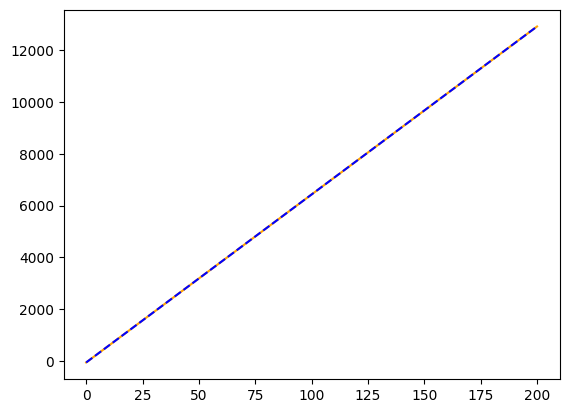

In [7]:
def V0_by_tree(alpha):
    ex7opt = Ex7Option(K, alpha)
    return ex7opt.price(model)

V0_vals_by_tree = [V0_by_tree(alpha) for alpha in alpha_vals]
plt.plot(alpha_vals, V0_vals_by_tree, color='orange')
plt.plot(alpha_vals, V0_vals_by_hand, color='blue', linestyle='--')
plt.show()